In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv("data.csv")

# reduce size for speed
data = data.sample(5000, random_state=42)

print(data.head())

            FILENAME                                                URL  \
136221    827598.txt                          https://www.northcm.ac.th   
56609   oph00308.txt  https://unitedmartialartscenters.com/at0/mygov...   
46393    8112660.txt  https://email.mail1.onesignal.os.tc/c/ejwcz02u...   
129746   8135291.txt                                http://uqr.to/1il1z   
131464    586561.txt               https://www.woolworthsrewards.com.au   

        URLLength                        Domain  DomainLength  IsDomainIP  \
136221         24             www.northcm.ac.th            17           0   
56609          59  unitedmartialartscenters.com            28           0   
46393         385   email.mail1.onesignal.os.tc            27           0   
129746         19                        uqr.to             6           0   
131464         35  www.woolworthsrewards.com.au            28           0   

        TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  \
13622

In [2]:
print("Shape:", data.shape)
print("Missing:", data.isnull().sum().sum())

Shape: (5000, 56)
Missing: 0


In [3]:
data.fillna(data.mean(numeric_only=True), inplace=True)

for col in data.select_dtypes('object'):
    data[col] = LabelEncoder().fit_transform(data[col])

# CHANGE 'label' if needed
X = data.drop('label', axis=1)
y = data['label']

print("Preprocessing Done")

Preprocessing Done


In [4]:
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Perceptron
p_model = Perceptron().fit(X_train, y_train)
y_pred_p = p_model.predict(X_test)

# MLP (with hidden layer)
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

Perceptron Accuracy: 0.9992
MLP Accuracy: 0.9984


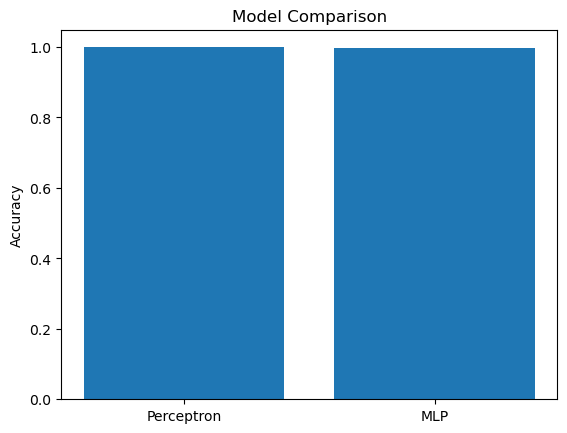

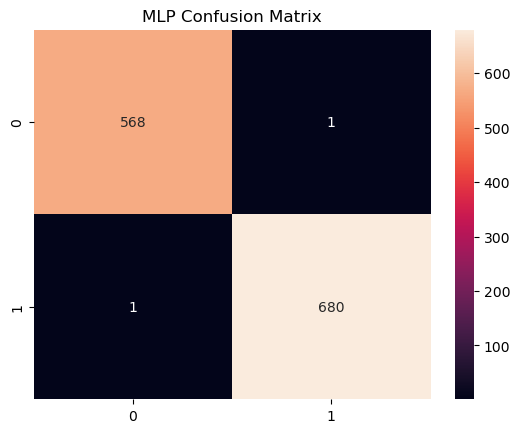

In [5]:
# Accuracy comparison
acc_p = accuracy_score(y_test, y_pred_p)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("Perceptron Accuracy:", acc_p)
print("MLP Accuracy:", acc_mlp)

# Graph: Accuracy Comparison
plt.bar(["Perceptron", "MLP"], [acc_p, acc_mlp])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

# Confusion Matrix for MLP
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("MLP Confusion Matrix")
plt.show()